Age min: 38.37379
Age max: 801662.0


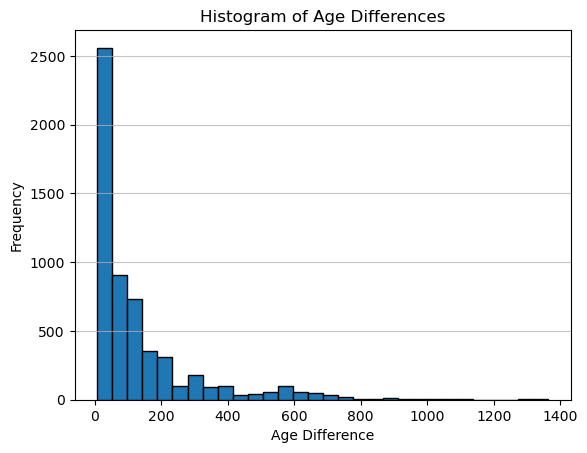

In [2]:
import pandas as pd

file_path = r"D:\VScode\Inso_LGMR\icecore_data\EDC_temp_Jouzel2007.txt"

# 1) Read in, letting pandas use the first line as header
df = pd.read_csv(
    file_path,
    delim_whitespace=True,
    comment='#',
    header=0              # <-- treat the first non-comment line as column names
)

# 2) Select only the two columns, rename them, and drop NaNs
df = (
    df[['Age', 'Temperature']]
      .rename(columns={'Age': 'age', 'Temperature': 'temp'})
      .dropna(subset=['age', 'temp'])
)

# (Optional) convert to numeric if they're still objects
df['age'] = df['age'].astype(float)
df['temp'] = df['temp'].astype(float)

# print the age min and max
print(f"Age min: {df['age'].min()}")
print(f"Age max: {df['age'].max()}")



import matplotlib.pyplot as plt
import numpy as np

# Calculate the differences between consecutive ages
age_diffs = np.diff(df['age'])
# Plot the histogram of the age differences
plt.hist(age_diffs, bins=30, edgecolor='black')
plt.xlabel('Age Difference')
plt.ylabel('Frequency')
plt.title('Histogram of Age Differences')
plt.grid(axis='y', alpha=0.75)
plt.show()

,age,temp
0,0,-8.898346
1,100,-8.894669
2,200,-8.890993
3,300,-8.887316
4,400,-8.883640
...,...,...
7995,799500,-1.688654
7996,799600,-0.332781
7997,799700,0.115777
7998,799800,0.196428


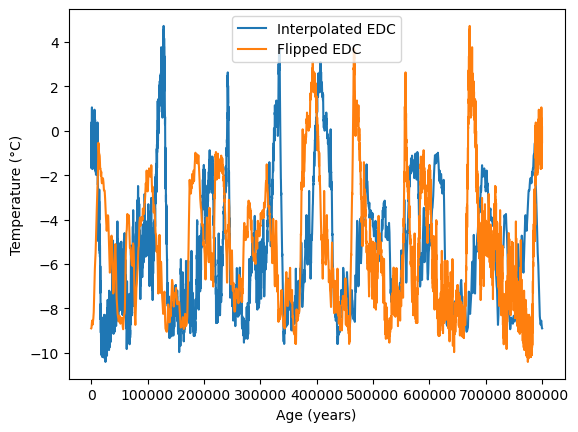

In [3]:
import numpy as np
import pandas as pd


df = df.sort_values('age')


new_age = np.arange(100, 800_001, 100)  # from 100 to 800000 inclusive

new_temp = np.interp(new_age, df['age'], df['temp'])

# 3) put into a DataFrame
df_edc = pd.DataFrame({
    'age': new_age,
    'temp': new_temp
})

# plot df_edc
plt.plot(df_edc['age'], df_edc['temp'], label='Interpolated EDC')
# plt.xlabel('Age (years)')

df_edc = df_edc.iloc[::-1]
# reindex the DataFrame to start from 0
df_edc.reset_index(drop=True, inplace=True)
df_edc['age'] = df_edc['age'].values*-1+np.max(new_age)
# plot flipped df_edc
plt.plot(df_edc['age'], df_edc['temp'], label='Flipped EDC')
plt.xlabel('Age (years)')
plt.ylabel('Temperature (°C)')
plt.legend()

# save to csv
df_edc.to_csv(r"D:\VScode\Inso_LGMR\icecore_data\edc_temp.csv", index=False)

df_edc


,age,pre
0,0.0,0.011391
1,100.0,0.011782
2,200.0,0.012161
3,300.0,0.012527
4,400.0,0.012880
...,...,...
7995,799500.0,0.016891
7996,799600.0,0.016798
7997,799700.0,0.016690
7998,799800.0,0.016568


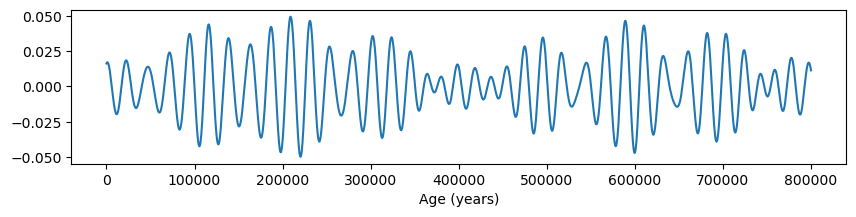

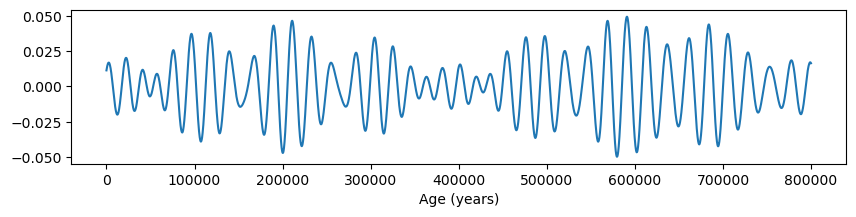

In [4]:
import pandas as pd

# Read the file into a DataFrame
df_pre = pd.read_csv(
    r"D:\VScode\Inso_LGMR\inso_data\pre_800.txt", 
    sep='\s+',       # '\s+' means "split on any whitespace"
    header=None,     # or specify a row number if there's a header
    engine='python'
)


df_pre.iloc[:, 0] = df_pre.iloc[:, 0].abs() * 1000

# plot the data
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 2))
plt.plot(df_pre.iloc[:, 0], df_pre.iloc[:, 1])
plt.xlabel('Age (years)')

# Rename the columns
df_pre.columns = ['age', 'pre']

# crop the data for age>=100 <=23900
df_pre = df_pre[(df_pre['age'] >= 100) & (df_pre['age'] <= 800000)]

# df_pre = df_pre[df_pre['age'] % 200 != 0]

# the age column * -1 +24000
df_pre['age'] = df_pre['age'] * -1 + 800_000

df_pre.to_csv(r"D:\VScode\Inso_LGMR\inso_data\pre_800.csv", index=False)

from matplotlib import pyplot as plt

plt.figure(figsize=(10, 2))
plt.plot(df_pre.iloc[:, 0], df_pre.iloc[:, 1])
plt.xlabel('Age (years)')

df_pre


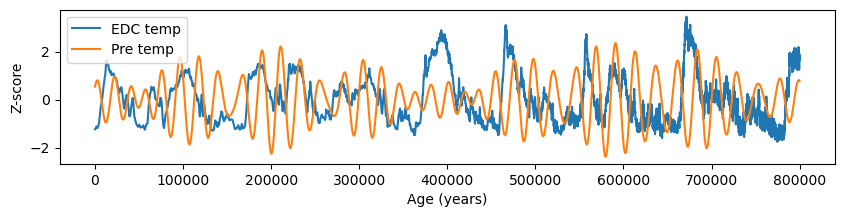

In [5]:
import pandas as pd
import plotly.graph_objects as go
from scipy.stats import zscore

# 1) Load the data
df_edc = pd.read_csv(r"D:\VScode\Inso_LGMR\icecore_data\edc_temp.csv")
df_pre = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre_800.csv")

# 2) Compute z‑scores
df_edc['temp_z'] = zscore(df_edc['temp'])
df_pre['pre_z']  = zscore(df_pre['pre'])

# 3) Build interactive figure
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_edc['age'],
    y=df_edc['temp_z'],
    mode='lines',
    name='EDC Temp (z)',
    line=dict(width=2)
))

fig.add_trace(go.Scatter(
    x=df_pre['age'],
    y=df_pre['pre_z'],
    mode='lines',
    name='Precession (z)',
    line=dict(width=2)
))

# 4) Layout tweaks: axes labels, title, range slider
fig.update_layout(
    title="EDC Temperature vs. Precession (Z‑score)",
    xaxis_title="Age (years BP)",
    yaxis_title="Z‑score",
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    xaxis=dict(
        rangeslider=dict(visible=True),
        type="linear"
    ),
    margin=dict(t=50, b=40, l=40, r=20)
)

# 5) Show it
fig.show()


# plot temp and pre, normalized the data using zscore
from scipy.stats import zscore
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 2))
plt.plot(df_edc['age'], zscore(df_edc['temp']), label='EDC temp')
plt.plot(df_pre['age'], zscore(df_pre['pre']), label='Pre temp')

plt.xlabel('Age (years)')
plt.ylabel('Z-score')
plt.legend()
plt.show()

In [32]:
df_edc.info
df_pre.info

<bound method DataFrame.info of            age       pre
0          0.0  0.011391
1        100.0  0.011782
2        200.0  0.012161
3        300.0  0.012527
4        400.0  0.012880
...        ...       ...
7995  799500.0  0.016891
7996  799600.0  0.016798
7997  799700.0  0.016690
7998  799800.0  0.016568
7999  799900.0  0.016431

[8000 rows x 2 columns]>

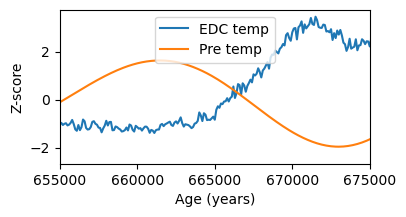

In [41]:
from scipy.stats import zscore
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(4, 2))
plt.plot(df_edc['age'], zscore(df_edc['temp']), label='EDC temp')
plt.plot(df_pre['age'], zscore(df_pre['pre']), label='Pre temp')
# set xlim to 670000 to 690000
plt.xlim(655000, 675000)
plt.xlabel('Age (years)')
plt.ylabel('Z-score')
plt.legend()
plt.show()

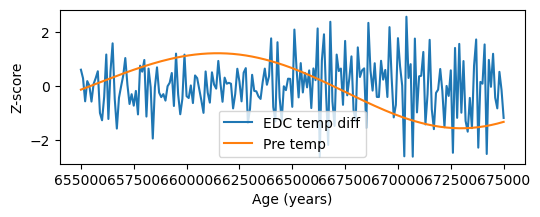

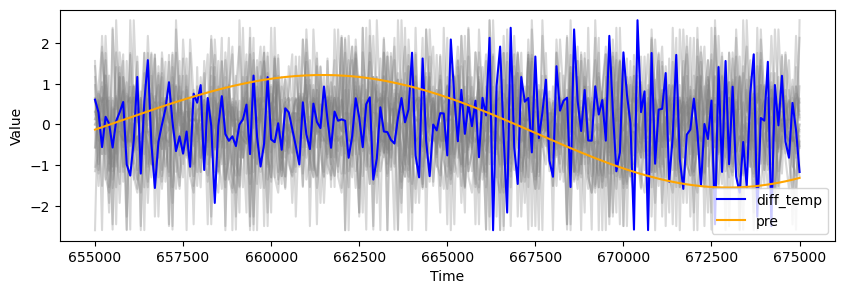

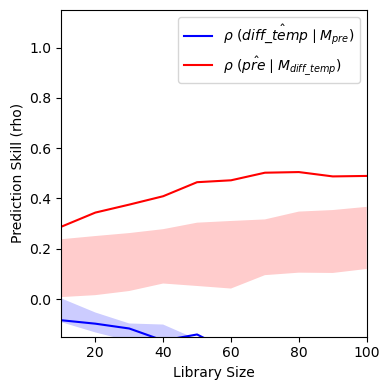

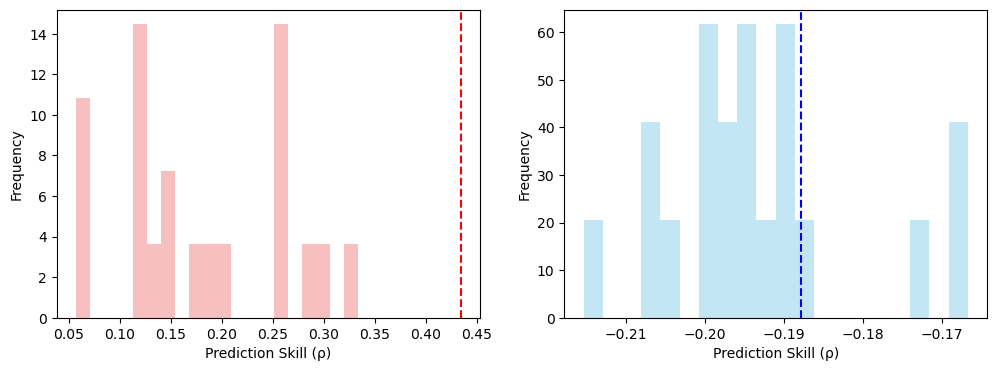

(True, False)


In [46]:
from toolbox import significant_test as st
import importlib
importlib.reload(st)

df_edc['diff_temp'] = df_edc['temp'].diff()
df_merged = pd.DataFrame({
    'age':       df_edc['age'].iloc[1:].values,
    'diff_temp': df_edc['diff_temp'].iloc[1:].values,
    'pre':       df_pre['pre'].iloc[1:].values
})

# crop the df_merged for age>=670000 <=690000
df_merged_crop=df_merged.copy()

data_start=655000
data_end=675000

# data_start=670000
# data_end=690000
df_merged_crop = df_merged_crop[(df_merged_crop['age'] >= data_start) & (df_merged_crop['age'] <= data_end)]

# plot the data
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 2))
plt.plot(df_merged_crop['age'], zscore(df_merged_crop['diff_temp']), label='EDC temp diff')
plt.plot(df_merged_crop['age'], zscore(df_merged_crop['pre']), label='Pre temp')
plt.xlabel('Age (years)')
plt.ylabel('Z-score')
plt.legend()
plt.show()


ccm_out, ran_ccm_list,test_result = st.ccm_significance_test_v2_df(
    df_input      = df_merged_crop,
    E         = 5,
    tau       = -3,
    Tp =0,
    n_ran     = 20,
    libSizes  = "10 20 30 40 50 60 70 80 90 100",
    random=True,
    sample    = 10,
    showPlot  = True
)

# print test_result
print(test_result)

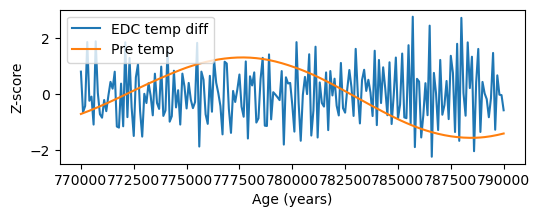

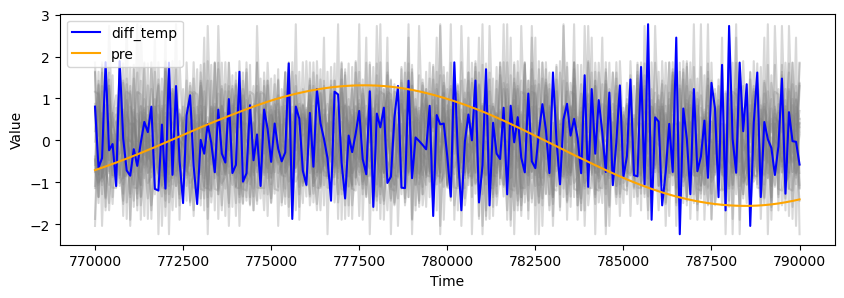

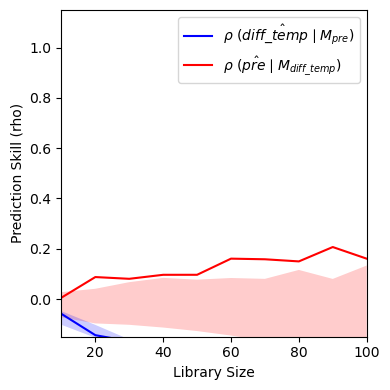

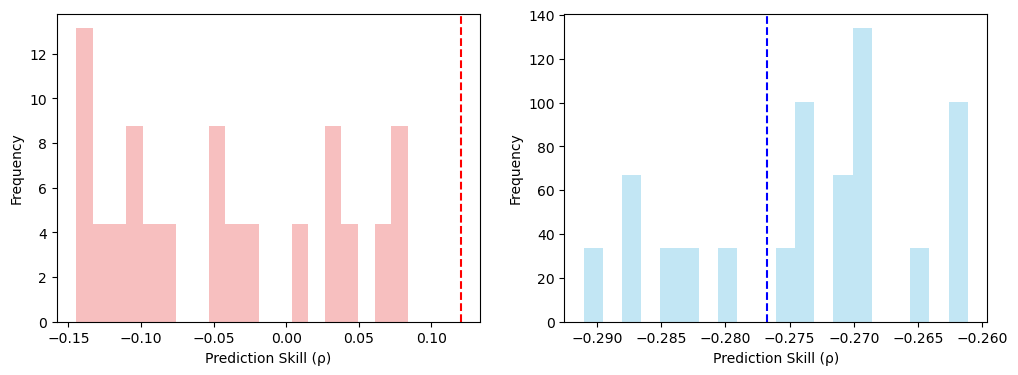

(True, False)


In [52]:
from toolbox import significant_test as st
import importlib
importlib.reload(st)

df_edc['diff_temp'] = df_edc['temp'].diff()
df_merged = pd.DataFrame({
    'age':       df_edc['age'].iloc[1:].values,
    'diff_temp': df_edc['diff_temp'].iloc[1:].values,
    'pre':       df_pre['pre'].iloc[1:].values
})

# crop the df_merged for age>=670000 <=690000
df_merged_crop=df_merged.copy()

data_start=770000
data_end=790000

# data_start=670000
# data_end=690000
df_merged_crop = df_merged_crop[(df_merged_crop['age'] >= data_start) & (df_merged_crop['age'] <= data_end)]

# plot the data
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 2))
plt.plot(df_merged_crop['age'], zscore(df_merged_crop['diff_temp']), label='EDC temp diff')
plt.plot(df_merged_crop['age'], zscore(df_merged_crop['pre']), label='Pre temp')
plt.xlabel('Age (years)')
plt.ylabel('Z-score')
plt.legend()
plt.show()


ccm_out, ran_ccm_list,test_result = st.ccm_significance_test_v2_df(
    df_input      = df_merged_crop,
    E         = 5,
    tau       = -3,
    Tp =0,
    n_ran     = 20,
    libSizes  = "10 20 30 40 50 60 70 80 90 100",
    random=True,
    sample    = 10,
    showPlot  = True
)

# print test_result
print(test_result)

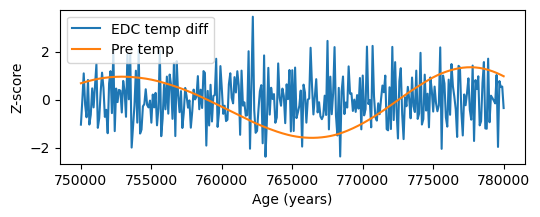

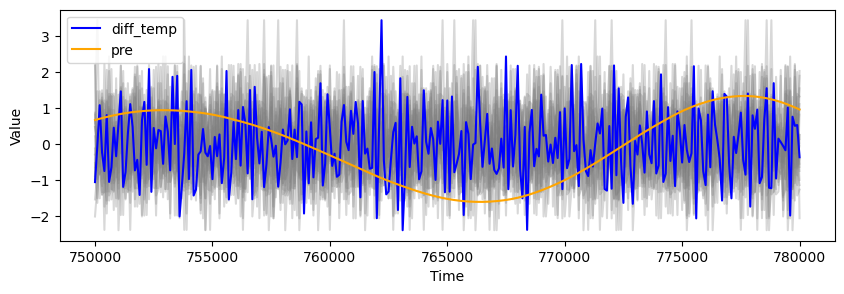

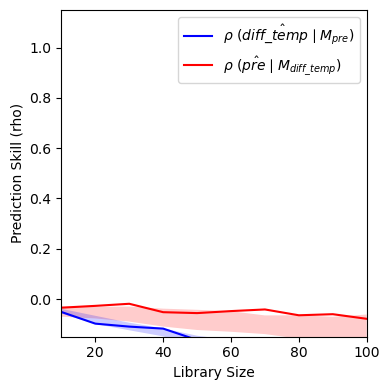

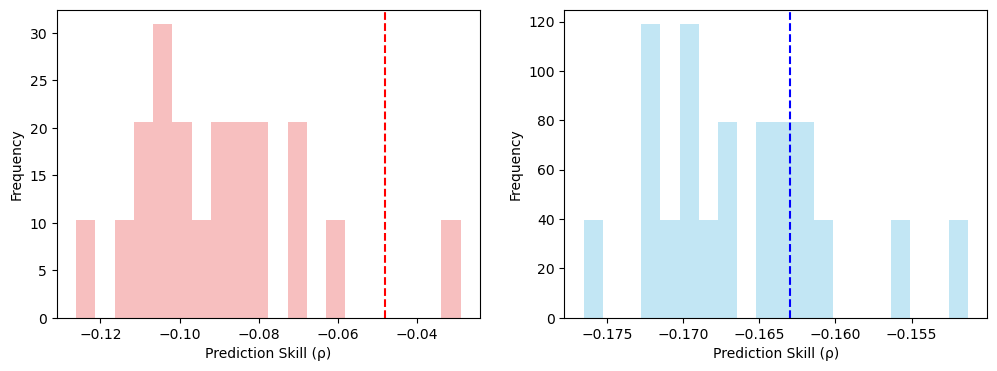

(True, False)


In [7]:
from toolbox import significant_test as st
import importlib
importlib.reload(st)

df_edc['diff_temp'] = df_edc['temp'].diff()
df_merged = pd.DataFrame({
    'age':       df_edc['age'].iloc[1:].values,
    'diff_temp': df_edc['diff_temp'].iloc[1:].values,
    'pre':       df_pre['pre'].iloc[1:].values
})

# crop the df_merged for age>=670000 <=690000
df_merged_crop=df_merged.copy()

data_start=750000
data_end=780000

# data_start=670000
# data_end=690000
df_merged_crop = df_merged_crop[(df_merged_crop['age'] >= data_start) & (df_merged_crop['age'] <= data_end)]

# plot the data
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 2))
plt.plot(df_merged_crop['age'], zscore(df_merged_crop['diff_temp']), label='EDC temp diff')
plt.plot(df_merged_crop['age'], zscore(df_merged_crop['pre']), label='Pre temp')
plt.xlabel('Age (years)')
plt.ylabel('Z-score')
plt.legend()
plt.show()


ccm_out, ran_ccm_list,test_result = st.ccm_significance_test_v2_df(
    df_input      = df_merged_crop,
    E         = 5,
    tau       = -3,
    Tp =0,
    n_ran     = 20,
    libSizes  = "10 20 30 40 50 60 70 80 90 100",
    random=True,
    sample    = 10,
    showPlot  = True
)

# print test_result
print(test_result)

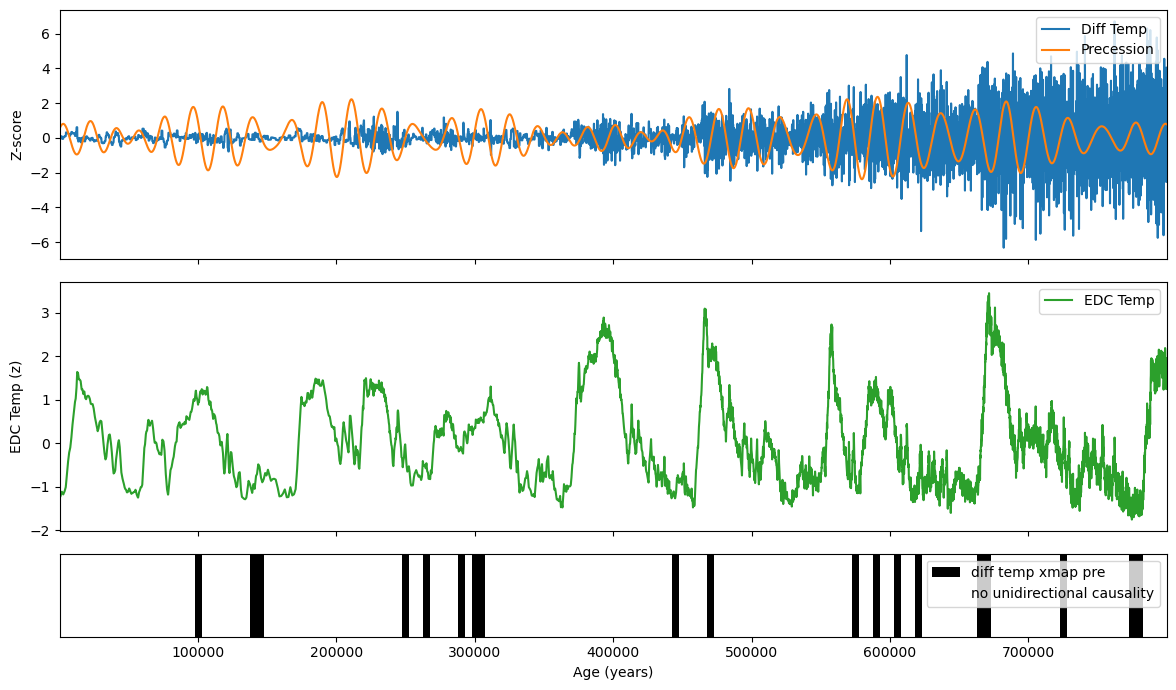

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from scipy.stats import zscore
from toolbox import significant_test as st
import importlib
importlib.reload(st)

# 1) Compute diff of temperature and align with precession
df_edc['diff_temp'] = df_edc['temp'].diff()
df_merged = pd.DataFrame({
    'age':       df_edc['age'].iloc[1:].values,
    'diff_temp': df_edc['diff_temp'].iloc[1:].values,
    'pre':       df_pre['pre'].iloc[1:].values
})

# 2) Sliding‐window CCM test (20 kyr window, 10 kyr step)
window_len = 20_000 // 100
step_len   = 5_000 // 100

test_results = []
window_centers = []
for start in range(0, len(df_merged) - window_len + 1, step_len):
    df_win = df_merged.iloc[start:start + window_len]
    _, _, test_result = st.ccm_significance_test_v2_df(
        df_input      = df_win,
        E             = 5,
        tau           = -3,
        Tp            = 0,
        n_ran         = 20,
        libSizes      = "50 100 150 180",
        random        = True,
        sample        = 50,
        showPlot      = False
    )
    test_results.append(test_result)
    window_centers.append(df_win['age'].iloc[window_len // 2])

# 3) Only flag pre→diff_temp unidirectional causality
categories = np.array([sig and (not non_sig) 
                       for sig, non_sig in test_results], dtype=int)

# 4) Plot: three rows, with a shorter middle panel
fig, (ax_ts, ax_mid, ax_strip) = plt.subplots(
    3, 1,
    figsize=(12, 7),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 3, 1]}
)

# Top panel: diff_temp & precession
ax_ts.plot(df_merged['age'], zscore(df_merged['diff_temp']), label='Diff Temp')
ax_ts.plot(df_merged['age'], zscore(df_merged['pre']),       label='Precession')
ax_ts.set_ylabel('Z‑score')
ax_ts.legend(loc='upper right')

# Middle panel: EDC temperature (z‑scored)
ax_mid.plot(df_edc['age'], zscore(df_edc['temp']), color='C2', label='EDC Temp')
ax_mid.set_ylabel('EDC Temp (z)')
ax_mid.legend(loc='upper right')

# Bottom strip: causality (1=pre→diff_temp in black, 0=none in white)
cmap = ListedColormap(['white', 'black'])
extent = [
    window_centers[0] - (step_len * 100) / 2,
    window_centers[-1] + (step_len * 100) / 2,
    0, 1
]
ax_strip.imshow(
    categories[np.newaxis, :],
    aspect='auto',
    cmap=cmap,
    extent=extent
)
ax_strip.set_yticks([])
ax_strip.set_xlabel('Age (years)')
ax_strip.set_xlim(df_merged['age'].min(), df_merged['age'].max())

legend_items = [
    Patch(facecolor='black', label='diff temp xmap pre'),
    Patch(facecolor='white', label='no unidirectional causality')
]
ax_strip.legend(handles=legend_items, loc='upper right')

plt.tight_layout()
plt.show()


# Smooth the data

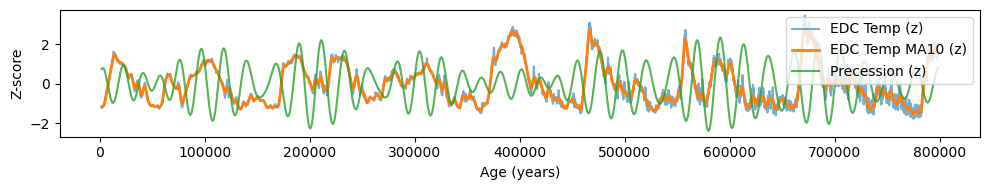

In [58]:
import pandas as pd
import plotly.graph_objects as go
from scipy.stats import zscore
import matplotlib.pyplot as plt
import numpy as np

# 1) Load the data
df_edc = pd.read_csv(r"D:\VScode\Inso_LGMR\icecore_data\edc_temp.csv")
df_pre = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre_800.csv")

# 2) Compute z‑scores
df_edc['temp_z'] = zscore(df_edc['temp'])
df_pre['pre_z']  = zscore(df_pre['pre'])

# 3) Smooth the EDC temp with a 10‑point moving average, eliminating NaNs
df_edc['temp_z_smooth'] = df_edc['temp_z'].rolling(window=30, center=True).mean()

# crop the NaNs in df_edc and crop df_pre for the same age range
df_edc = df_edc.dropna(subset=['temp_z_smooth'])
df_pre = df_pre[(df_pre['age'] >= df_edc['age'].min()) & (df_pre['age'] <= df_edc['age'].max())]

# --- Plotly interactive figure ---
fig = go.Figure()

# raw z‑score
fig.add_trace(go.Scatter(
    x=df_edc['age'],
    y=df_edc['temp_z'],
    mode='lines',
    name='EDC Temp (z)',
    line=dict(width=2)
))

# smoothed
fig.add_trace(go.Scatter(
    x=df_edc['age'],
    y=df_edc['temp_z_smooth'],
    mode='lines',
    name='EDC Temp (z, MA10)',
    line=dict(width=2)
))

# precession
fig.add_trace(go.Scatter(
    x=df_pre['age'],
    y=df_pre['pre_z'],
    mode='lines',
    name='Precession (z)',
    line=dict(width=2)
))

fig.update_layout(
    title="EDC Temperature vs. Precession (Z‑score, with MA10)",
    xaxis_title="Age (years BP)",
    yaxis_title="Z‑score",
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    xaxis=dict(rangeslider=dict(visible=True), type="linear"),
    margin=dict(t=50, b=40, l=40, r=20)
)

fig.show()

# --- Static Matplotlib figure ---
plt.figure(figsize=(10, 2))
plt.plot(df_edc['age'], df_edc['temp_z'],           label='EDC Temp (z)',      alpha=0.6)
plt.plot(df_edc['age'], df_edc['temp_z_smooth'],    label='EDC Temp MA10 (z)', linewidth=2)
plt.plot(df_pre['age'], df_pre['pre_z'],            label='Precession (z)',    alpha=0.8)

plt.xlabel('Age (years)')
plt.ylabel('Z-score')
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
df_edc

,age,temp,temp_z,temp_z_smooth
5,500,-8.879679,-1.231672,-1.222547
6,600,-8.847543,-1.220597,-1.216366
7,700,-8.815406,-1.209522,-1.209204
8,800,-8.783270,-1.198447,-1.201062
9,900,-8.751134,-1.187372,-1.191938
...,...,...,...,...
7991,799100,0.395817,1.964948,1.803521
7992,799200,0.073465,1.853856,1.792971
7993,799300,-0.496780,1.657332,1.760690
7994,799400,-0.839966,1.539060,1.736554


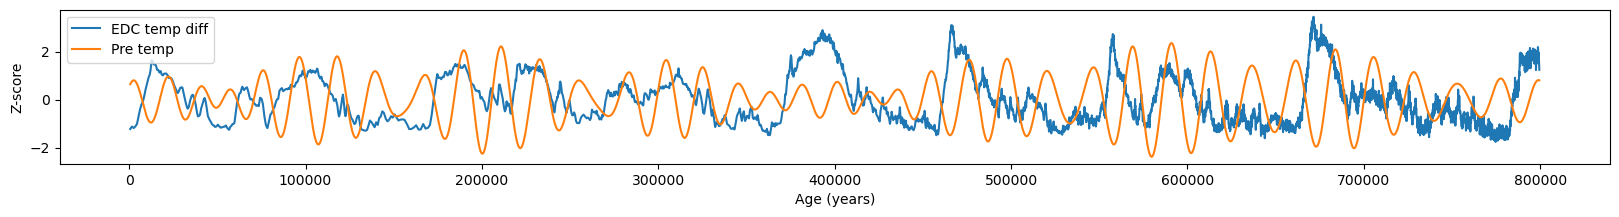

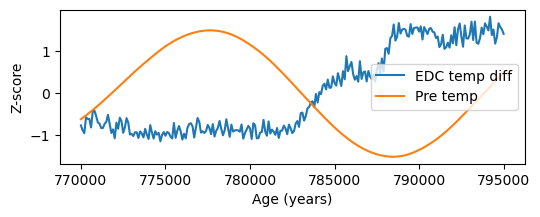

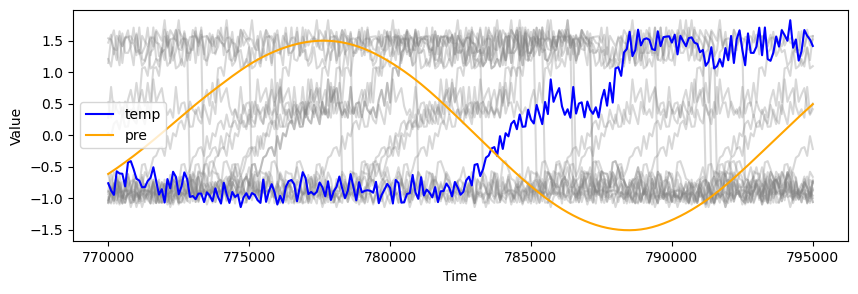

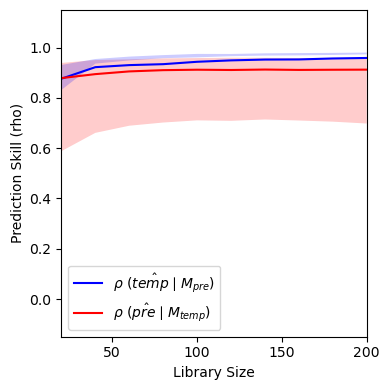

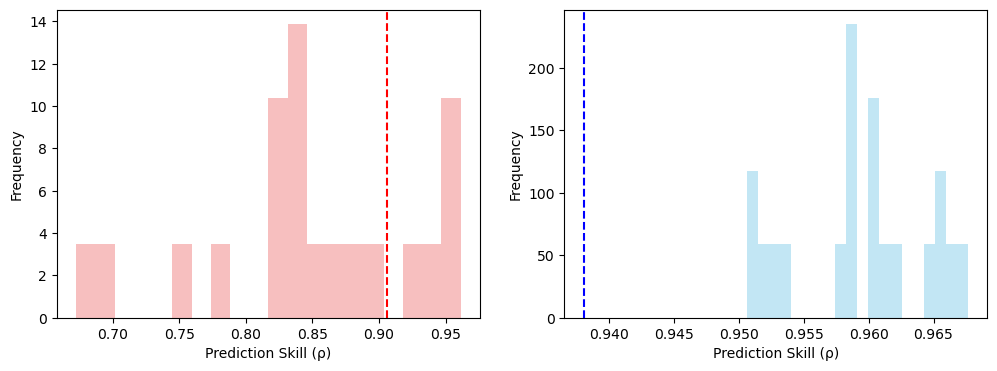

(False, False)


In [50]:
# df_edc['diff_temp'] = df_edc['temp_z_smooth'].diff()
df_merged = pd.DataFrame({
    'age':       df_edc['age'].iloc[1:].values,
    'temp': df_edc['temp'].iloc[1:].values,
    'pre':       df_pre['pre'].iloc[1:].values
})


# plot the data
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 2))
plt.plot(df_merged['age'], zscore(df_merged['temp']), label='EDC temp diff')
# plt.plot(df_merged['age'], zscore(df_merged['diff_temp_smooth']), label='EDC temp diff smooth')
plt.plot(df_merged['age'], zscore(df_merged['pre']), label='Pre temp')
plt.xlabel('Age (years)')
plt.ylabel('Z-score')
plt.legend()
plt.show()



df_merged_crop=df_merged.copy()

data_start=770000
data_end=795000

# data_start=0
# data_end=800000

# data_start=670000
# data_end=690000
df_merged_crop = df_merged_crop[(df_merged_crop['age'] >= data_start) & (df_merged_crop['age'] <= data_end)]

# plot the data
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 2))
plt.plot(df_merged_crop['age'], zscore(df_merged_crop['temp']), label='EDC temp diff')
plt.plot(df_merged_crop['age'], zscore(df_merged_crop['pre']), label='Pre temp')
plt.xlabel('Age (years)')
plt.ylabel('Z-score')
plt.legend()
plt.show()


ccm_out, ran_ccm_list,test_result = st.ccm_significance_test_v2_df(
    df_input      = df_merged_crop,
    E         = 5,
    tau       = -6,
    Tp =0,
    n_ran     = 20,
    libSizes  = "20 40 60 80 100 120 140 160 180 200",
    random=True,
    sample    = 20,
    showPlot  = True
)

# print test_result
print(test_result)

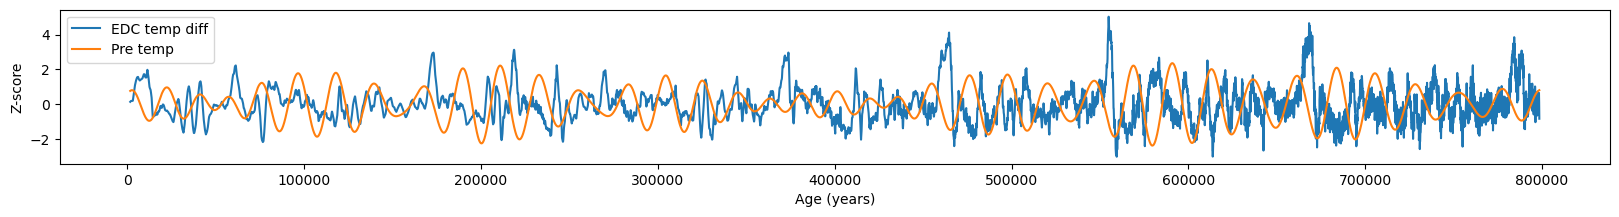

In [59]:
df_edc['diff_temp'] = df_edc['temp_z_smooth'].diff()
df_merged = pd.DataFrame({
    'age':       df_edc['age'].iloc[1:].values,
    'diff_temp': df_edc['diff_temp'].iloc[1:].values,
    'pre':       df_pre['pre'].iloc[1:].values
})

# df_merged= df_merged_ori.copy()
# # smooth the df_merged diff_temp with a 10‑point moving average, eliminating NaNs
# df_merged['diff_temp_smooth'] = df_merged['diff_temp'].rolling(window=30, center=True).mean()
# # crop the NaNs in df_merged
# df_merged = df_merged.dropna(subset=['diff_temp_smooth'])



# plot the data
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 2))
plt.plot(df_merged['age'], zscore(df_merged['diff_temp']), label='EDC temp diff')
# plt.plot(df_merged['age'], zscore(df_merged['diff_temp_smooth']), label='EDC temp diff smooth')
plt.plot(df_merged['age'], zscore(df_merged['pre']), label='Pre temp')
plt.xlabel('Age (years)')
plt.ylabel('Z-score')
plt.legend()
plt.show()

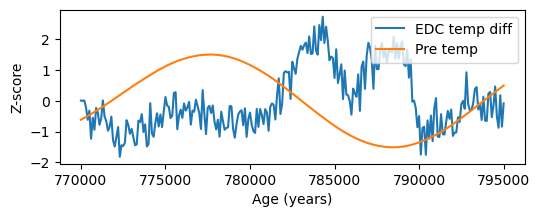

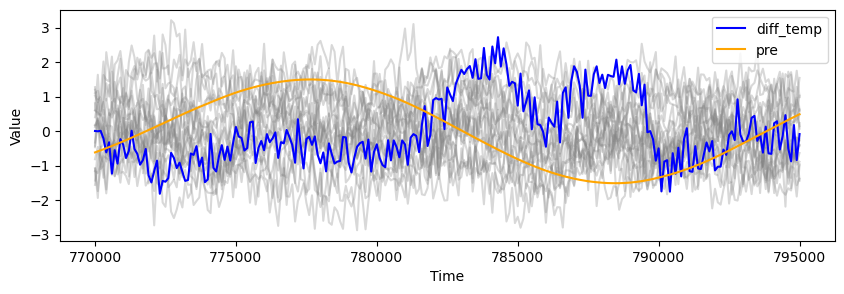

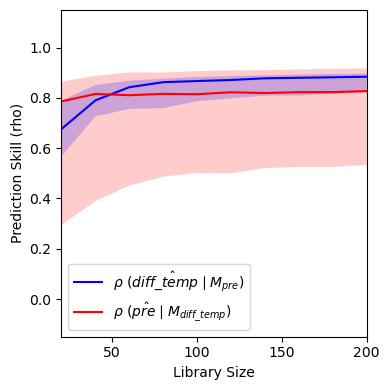

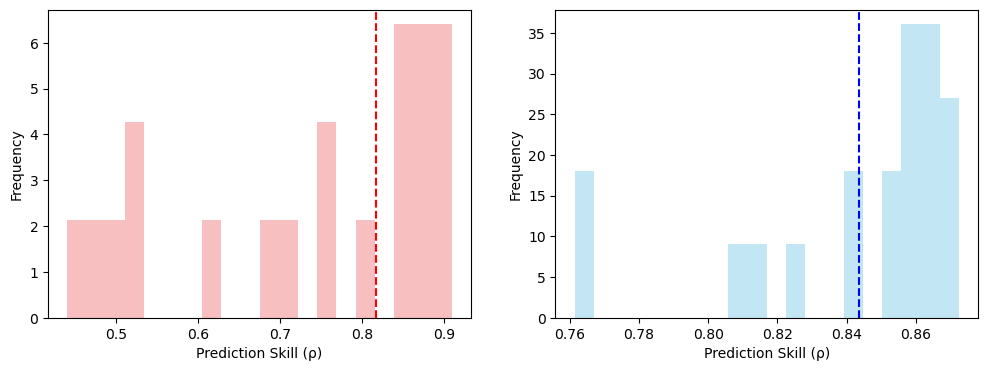

(False, False)


In [61]:
from toolbox import significant_test as st
import importlib
importlib.reload(st)

# crop the df_merged for age>=670000 <=690000
df_merged_crop=df_merged.copy()

data_start=770000
data_end=795000

# data_start=670000
# data_end=690000
df_merged_crop = df_merged_crop[(df_merged_crop['age'] >= data_start) & (df_merged_crop['age'] <= data_end)]

# plot the data
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 2))
plt.plot(df_merged_crop['age'], zscore(df_merged_crop['diff_temp']), label='EDC temp diff')
plt.plot(df_merged_crop['age'], zscore(df_merged_crop['pre']), label='Pre temp')
plt.xlabel('Age (years)')
plt.ylabel('Z-score')
plt.legend()
plt.show()


# ccm_out, ran_ccm_list,test_result = st.ccm_significance_test_v2_df(
#     df_input      = df_merged_crop,
#     E         = 5,
#     tau       = -6,
#     Tp =0,
#     n_ran     = 20,
#     libSizes  = "20 40 60 80 100 120 140 160 180 200",
#     random=True,
#     sample    = 20,
#     showPlot  = True
# )

ccm_out, ran_ccm_list,test_result = st.ccm_significance_test_v3_df(
    df_input      = df_merged_crop,
    E         = 5,
    tau       = -6,
    Tp =0,
    n_ran     = 20,
    libSizes  = "20 40 60 80 100 120 140 160 180 200",
    random=True,
    sample    = 20,
    showPlot  = True
)

# print test_result
print(test_result)

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from scipy.stats import zscore
from toolbox import significant_test as st
import importlib
importlib.reload(st)

# # 1) Compute diff of temperature and align with precession
# df_edc['diff_temp'] = df_edc['temp'].diff()
# df_merged = pd.DataFrame({
#     'age':       df_edc['age'].iloc[1:].values,
#     'diff_temp': df_edc['diff_temp'].iloc[1:].values,
#     'pre':       df_pre['pre'].iloc[1:].values
# })

# 2) Sliding‐window CCM test (20 kyr window, 10 kyr step)
window_len = 20_000 // 100
step_len   = 5_000 // 100

test_results = []
window_centers = []
for start in range(0, len(df_merged) - window_len + 1, step_len):
    df_win = df_merged.iloc[start:start + window_len]
    _, _, test_result = st.ccm_significance_test_v2_df(
        df_input      = df_win,
        E             = 5,
        tau           = -3,
        Tp            = 0,
        n_ran         = 20,
        libSizes      = "50 100 150 180",
        random        = True,
        sample        = 50,
        showPlot      = False
    )
    test_results.append(test_result)
    window_centers.append(df_win['age'].iloc[window_len // 2])

# 3) Only flag pre→diff_temp unidirectional causality
categories = np.array([sig and (not non_sig) 
                       for sig, non_sig in test_results], dtype=int)

# 4) Plot: three rows, with a shorter middle panel
fig, (ax_ts, ax_mid, ax_strip) = plt.subplots(
    3, 1,
    figsize=(12, 7),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 3, 1]}
)

# Top panel: diff_temp & precession
ax_ts.plot(df_merged['age'], zscore(df_merged['diff_temp']), label='Diff Temp')
ax_ts.plot(df_merged['age'], zscore(df_merged['pre']),       label='Precession')
ax_ts.set_ylabel('Z‑score')
ax_ts.legend(loc='upper right')

# Middle panel: EDC temperature (z‑scored)
ax_mid.plot(df_edc['age'], zscore(df_edc['temp']), color='C2', label='EDC Temp')
ax_mid.set_ylabel('EDC Temp (z)')
ax_mid.legend(loc='upper right')

# Bottom strip: causality (1=pre→diff_temp in black, 0=none in white)
cmap = ListedColormap(['white', 'black'])
extent = [
    window_centers[0] - (step_len * 100) / 2,
    window_centers[-1] + (step_len * 100) / 2,
    0, 1
]
ax_strip.imshow(
    categories[np.newaxis, :],
    aspect='auto',
    cmap=cmap,
    extent=extent
)
ax_strip.set_yticks([])
ax_strip.set_xlabel('Age (years)')
ax_strip.set_xlim(df_merged['age'].min(), df_merged['age'].max())

legend_items = [
    Patch(facecolor='black', label='diff temp xmap pre'),
    Patch(facecolor='white', label='no unidirectional causality')
]
ax_strip.legend(handles=legend_items, loc='upper right')

plt.tight_layout()
plt.show()


KeyboardInterrupt: 

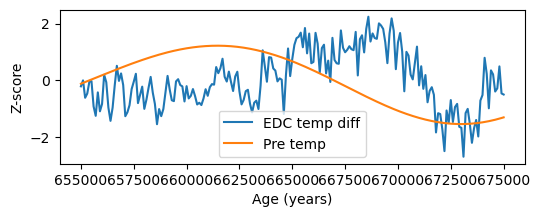

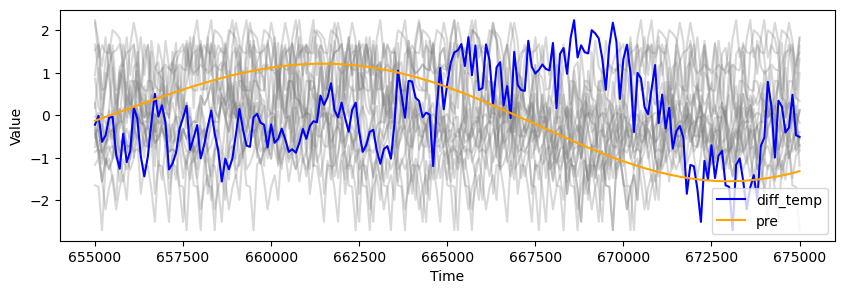

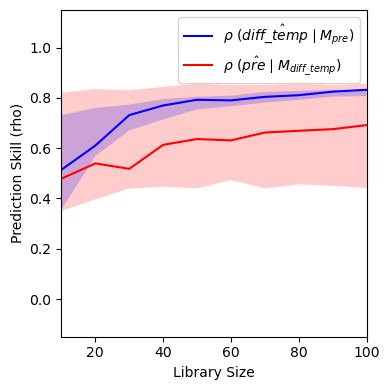

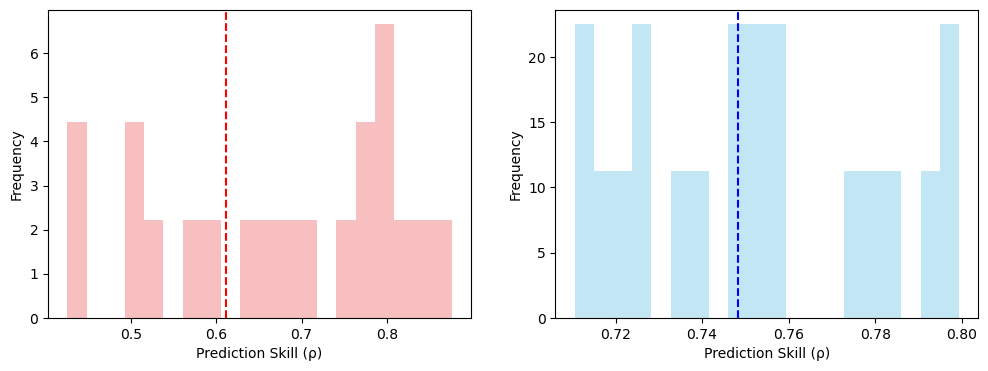

(False, False)


In [24]:
from toolbox import significant_test as st
import importlib
importlib.reload(st)


# crop the df_merged for age>=670000 <=690000
df_merged_crop=df_merged.copy()

data_start=655000
data_end=675000

# data_start=670000
# data_end=690000
df_merged_crop = df_merged_crop[(df_merged_crop['age'] >= data_start) & (df_merged_crop['age'] <= data_end)]

# plot the data
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 2))
plt.plot(df_merged_crop['age'], zscore(df_merged_crop['diff_temp']), label='EDC temp diff')
plt.plot(df_merged_crop['age'], zscore(df_merged_crop['pre']), label='Pre temp')
plt.xlabel('Age (years)')
plt.ylabel('Z-score')
plt.legend()
plt.show()


ccm_out, ran_ccm_list,test_result = st.ccm_significance_test_v2_df(
    df_input      = df_merged_crop,
    E         = 5,
    tau       = -3,
    Tp =0,
    n_ran     = 20,
    libSizes  = "10 20 30 40 50 60 70 80 90 100",
    random=True,
    sample    = 10,
    showPlot  = True
)

# print test_result
print(test_result)

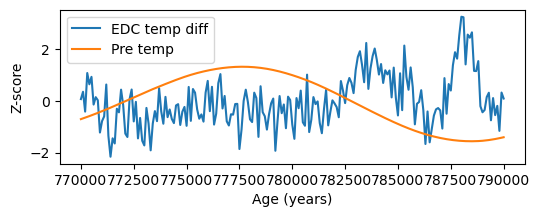

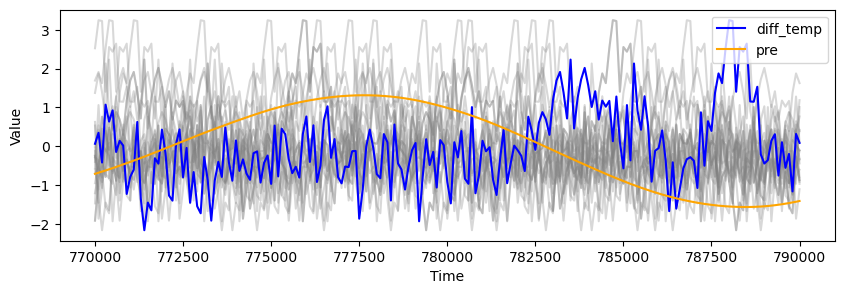

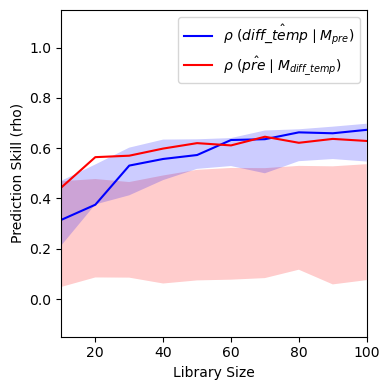

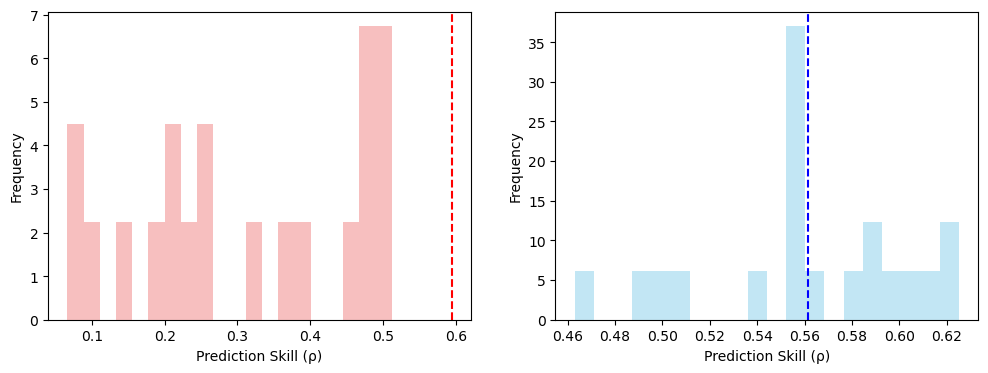

(True, False)


In [56]:
from toolbox import significant_test as st
import importlib
importlib.reload(st)

df_edc['diff_temp'] = df_edc['temp_z_smooth'].diff()
df_merged = pd.DataFrame({
    'age':       df_edc['age'].iloc[1:].values,
    'diff_temp': df_edc['diff_temp'].iloc[1:].values,
    'pre':       df_pre['pre'].iloc[1:].values
})

# crop the df_merged for age>=670000 <=690000
df_merged_crop=df_merged.copy()

data_start=770000
data_end=790000

# data_start=670000
# data_end=690000
df_merged_crop = df_merged_crop[(df_merged_crop['age'] >= data_start) & (df_merged_crop['age'] <= data_end)]

# plot the data
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 2))
plt.plot(df_merged_crop['age'], zscore(df_merged_crop['diff_temp']), label='EDC temp diff')
plt.plot(df_merged_crop['age'], zscore(df_merged_crop['pre']), label='Pre temp')
plt.xlabel('Age (years)')
plt.ylabel('Z-score')
plt.legend()
plt.show()


ccm_out, ran_ccm_list,test_result = st.ccm_significance_test_v2_df(
    df_input      = df_merged_crop,
    E         = 5,
    tau       = -3,
    Tp =0,
    n_ran     = 20,
    libSizes  = "10 20 30 40 50 60 70 80 90 100",
    random=True,
    sample    = 10,
    showPlot  = True
)

# print test_result
print(test_result)

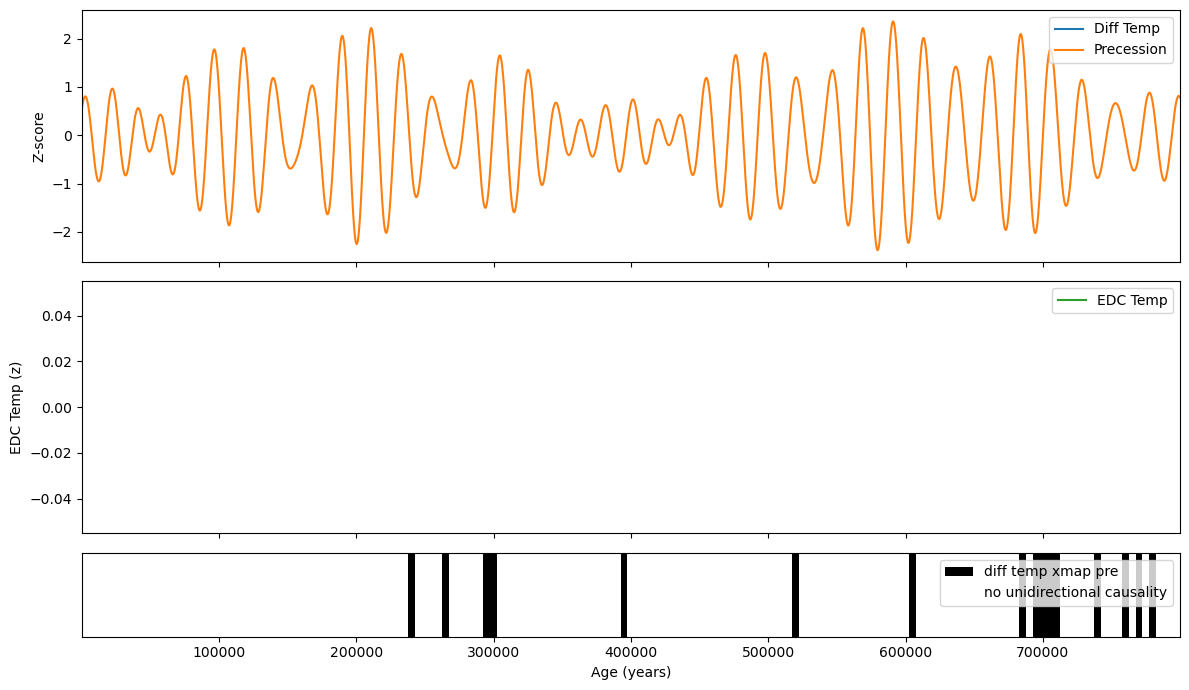

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from scipy.stats import zscore
from toolbox import significant_test as st
import importlib
importlib.reload(st)

# 1) Compute diff of temperature and align with precession
df_edc['diff_temp'] = df_edc['temp_z_smooth'].diff()
df_merged = pd.DataFrame({
    'age':       df_edc['age'].iloc[1:].values,
    'diff_temp': df_edc['diff_temp'].iloc[1:].values,
    'pre':       df_pre['pre'].iloc[1:].values
})

# 2) Sliding‐window CCM test (20 kyr window, 10 kyr step)
window_len = 20_000 // 100
step_len   = 5_000 // 100

test_results = []
window_centers = []
for start in range(0, len(df_merged) - window_len + 1, step_len):
    df_win = df_merged.iloc[start:start + window_len]
    _, _, test_result = st.ccm_significance_test_v2_df(
        df_input      = df_win,
        E             = 5,
        tau           = -3,
        Tp            = 0,
        n_ran         = 20,
        libSizes      = "50 100 150 180",
        random        = True,
        sample        = 50,
        showPlot      = False
    )
    test_results.append(test_result)
    window_centers.append(df_win['age'].iloc[window_len // 2])

# 3) Only flag pre→diff_temp unidirectional causality
categories = np.array([sig and (not non_sig) 
                       for sig, non_sig in test_results], dtype=int)

# 4) Plot: three rows, with a shorter middle panel
fig, (ax_ts, ax_mid, ax_strip) = plt.subplots(
    3, 1,
    figsize=(12, 7),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 3, 1]}
)

# Top panel: diff_temp & precession
ax_ts.plot(df_merged['age'], zscore(df_merged['diff_temp']), label='Diff Temp')
ax_ts.plot(df_merged['age'], zscore(df_merged['pre']),       label='Precession')
ax_ts.set_ylabel('Z‑score')
ax_ts.legend(loc='upper right')

# Middle panel: EDC temperature (z‑scored)
ax_mid.plot(df_edc['age'], zscore(df_edc['temp_z_smooth']), color='C2', label='EDC Temp')
ax_mid.set_ylabel('EDC Temp (z)')
ax_mid.legend(loc='upper right')

# Bottom strip: causality (1=pre→diff_temp in black, 0=none in white)
cmap = ListedColormap(['white', 'black'])
extent = [
    window_centers[0] - (step_len * 100) / 2,
    window_centers[-1] + (step_len * 100) / 2,
    0, 1
]
ax_strip.imshow(
    categories[np.newaxis, :],
    aspect='auto',
    cmap=cmap,
    extent=extent
)
ax_strip.set_yticks([])
ax_strip.set_xlabel('Age (years)')
ax_strip.set_xlim(df_merged['age'].min(), df_merged['age'].max())

legend_items = [
    Patch(facecolor='black', label='diff temp xmap pre'),
    Patch(facecolor='white', label='no unidirectional causality')
]
ax_strip.legend(handles=legend_items, loc='upper right')

plt.tight_layout()
plt.show()


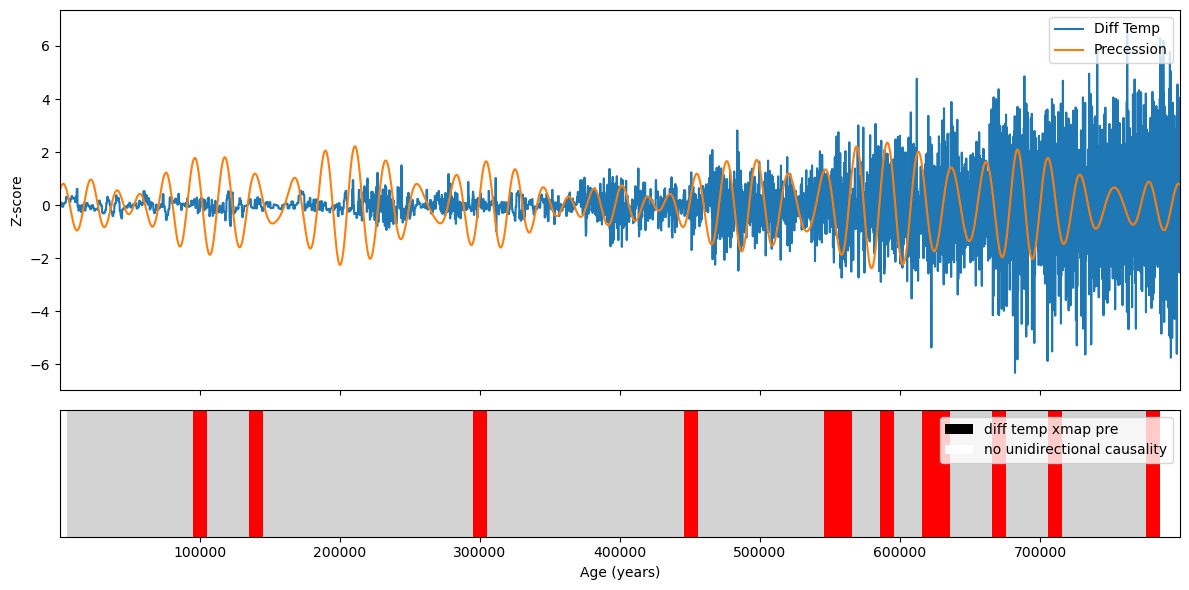

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from scipy.stats import zscore
from toolbox import significant_test as st
import importlib
importlib.reload(st)

# 1) Compute diff of temperature and align with precession
df_edc['diff_temp'] = df_edc['temp'].diff()
df_merged = pd.DataFrame({
    'age':       df_edc['age'].iloc[1:].values,
    'diff_temp': df_edc['diff_temp'].iloc[1:].values,
    'pre':       df_pre['pre'].iloc[1:].values
})

# 2) Sliding‐window CCM test (20 kyr window, 10 kyr step)
window_len = 20_000 // 100
step_len   = 10_000 // 100

test_results = []
window_centers = []
for start in range(0, len(df_merged) - window_len + 1, step_len):
    df_win = df_merged.iloc[start:start + window_len]
    _, _, test_result = st.ccm_significance_test_v2_df(
        df_input      = df_win,
        E             = 5,
        tau           = -3,
        Tp            = 0,
        n_ran         = 20,
        libSizes      = "10 20 30 40 50 60 70 80 90 100",
        random        = True,
        sample        = 10,
        showPlot      = False
    )
    test_results.append(test_result)
    window_centers.append(df_win['age'].iloc[window_len // 2])

# 3) Only flag pre→diff_temp unidirectional causality
#    True if (sig_forward AND not non_sig_reverse), else False
categories = np.array([sig and (not non_sig) 
                       for sig, non_sig in test_results], dtype=int)

# 4) Plot: taller top panel, shorter bottom strip
fig, (ax_ts, ax_strip) = plt.subplots(
    2, 1,
    figsize=(12, 6),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

# Time series (z‑scored)
ax_ts.plot(df_merged['age'], zscore(df_merged['diff_temp']), label='Diff Temp')
ax_ts.plot(df_merged['age'], zscore(df_merged['pre']),       label='Precession')
ax_ts.set_ylabel('Z‑score')
ax_ts.legend(loc='upper right')

# Causality strip: 1→red, 0→grey
cmap = ListedColormap(['white', 'black'])
extent = [
    window_centers[0] - (step_len * 100) / 2,
    window_centers[-1] + (step_len * 100) / 2,
    0, 1
]
ax_strip.imshow(
    categories[np.newaxis, :],
    aspect='auto',
    cmap=cmap,
    extent=extent
)
ax_strip.set_yticks([])
ax_strip.set_xlabel('Age (years)')
ax_strip.set_xlim(df_merged['age'].min(), df_merged['age'].max())

# Legend: only two entries
legend_items = [
    Patch(facecolor='black',       label='diff temp xmap pre'),
    Patch(facecolor='white', label='no unidirectional causality')
]
# ax_strip.legend(handles=legend_items, loc='upper right', ncol=2, frameon=False)
ax_strip.legend(handles=legend_items, loc='upper right')

plt.tight_layout()
plt.show()


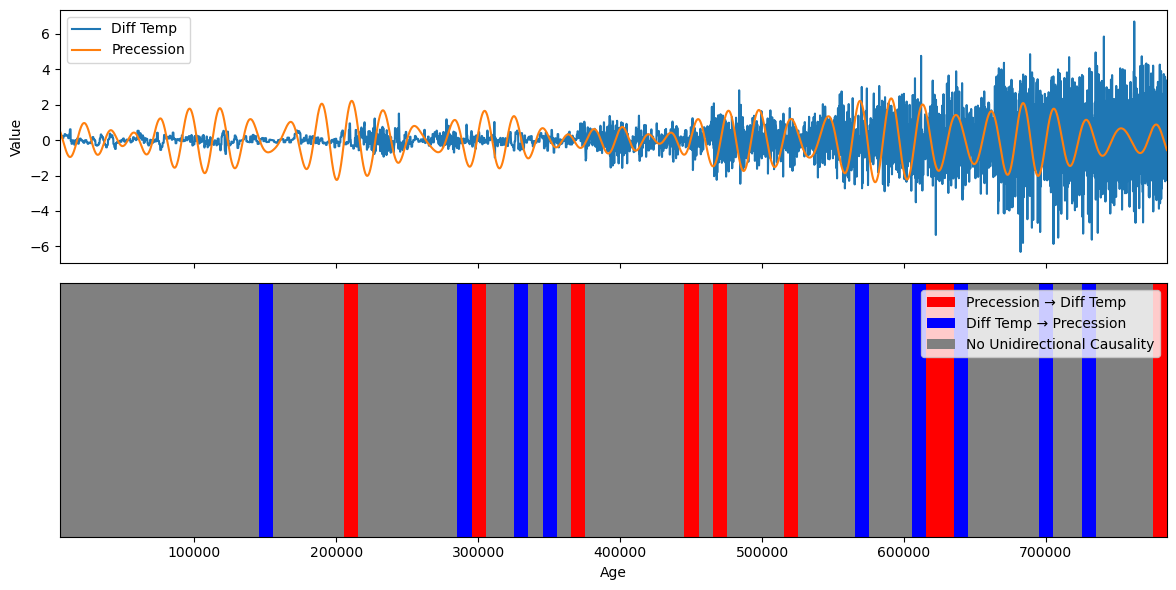

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from scipy.stats import zscore
from toolbox import significant_test as st
import importlib
importlib.reload(st)

# Ensure df_edc and df_pre are loaded, and ccm_significance_test_v2_df is defined in the environment.

# 1) Compute diff of temperature and align with precession
df_edc['diff_temp'] = df_edc['temp'].diff()
df_merged = pd.DataFrame({
    'age':       df_edc['age'].iloc[1:].values,
    'diff_temp': df_edc['diff_temp'].iloc[1:].values,
    'pre':       df_pre['pre'].iloc[1:].values
})

# 2) Set sliding-window parameters (20 kyr window, 10 kyr step; data step = 100 yr → 200 & 100 points)
window_len = 20_000 // 100
step_len   = 10_000 // 100

test_results = []
window_centers = []

for start in range(0, len(df_merged) - window_len + 1, step_len):
    df_win = df_merged.iloc[start:start + window_len]
    _, _, test_result = st.ccm_significance_test_v2_df(
            df_input      = df_merged_crop,
            E         = 5,
            tau       = -3,
            Tp =0,
            n_ran     = 20,
            libSizes  = "10 20 30 40 50 60 70 80 90 100",
            random=True,
            sample    = 10,
            showPlot  = True
        )
    test_results.append(test_result)
    # center of window in kyr
    window_centers.append(df_win['age'].iloc[window_len // 2])

# 3) Categorize causality outcomes: 0=pre→diff, 1=diff→pre, 2=no/other
categories = np.full(len(test_results), 2)
for i, (sig_forward, non_sig_reverse) in enumerate(test_results):
    if sig_forward and not non_sig_reverse:
        categories[i] = 0
    elif not sig_forward and non_sig_reverse:
        categories[i] = 1

# 4) Plot time series + causality strip
fig, (ax_ts, ax_strip) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Time series
ax_ts.plot(df_merged['age'], zscore(df_merged['diff_temp']), label='Diff Temp')
ax_ts.plot(df_merged['age'], zscore(df_merged['pre']),       label='Precession')
ax_ts.set_ylabel('Value')
ax_ts.legend()

# Causality strip
cmap = ListedColormap(['red', 'blue', 'grey'])
extent = [window_centers[0] - (step_len*100)/2,
          window_centers[-1] + (step_len*100)/2,
          0, 1]
ax_strip.imshow(categories[np.newaxis, :], aspect='auto', cmap=cmap, extent=extent)
ax_strip.set_yticks([])
ax_strip.set_xlabel('Age')
legend_items = [
    Patch(facecolor='red',  label='Precession → Diff Temp'),
    Patch(facecolor='blue', label='Diff Temp → Precession'),
    Patch(facecolor='grey', label='No Unidirectional Causality')
]
ax_strip.legend(handles=legend_items, loc='upper right')

plt.tight_layout()
plt.show()
